# Tutorial 2: Human fetal cortex

In [1]:
import remap
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

## Load ST reference and scRNA-seq data
##### Source data can be downloaded from the link: https://drive.google.com/drive/folders/109EcFFwDPrUV8lx9i6o1A69eBUDgmLNO
##### The batch effect corrected expressions are stored in `Rdata.obsm['corrected']` and `Qdata.obsm['corrected']`. If no external batch correction is applied, setting `harmony = TRUE` in the `remap.Fit_cord_iter` function will run Harmony internally to remove batch effects.

In [2]:
Rdata = ad.read_h5ad("data/v1v2/st_data.h5ad")
Qdata = ad.read_h5ad("data/v1v2/sc_data.h5ad")
print(Rdata)
print(Qdata)

data_name = "v1v2"
path_name =  f"remap_output/{data_name}"

AnnData object with n_obs × n_vars = 77881 × 300
    obs: 'x_cord', 'y_cord', 'source', 'n_counts', 'sample', 'region', 'gw', 'H1_cluster', 'H2_cluster', 'H3_cluster', 'H1_annotation', 'H2_annotation', 'Cluster'
    obsm: 'covet', 'spatial'
AnnData object with n_obs × n_vars = 28174 × 30968
    obs: 'source', 'Cluster', 'n_counts'
    var: 'features'
    obsm: 'X_umap', 'covet'


## Initialize neighboring gene-gene covariance estimation.

##### After training, initialized neighboring gene-gene covariance for ST and scRNA-seq will be saved to `path_name` in `npy` format.

In [ ]:
Rdata, Qdata = remap.covet_init(st_data = Rdata, sc_data = Qdata, num_covet_genes=100, k_nearest=100, num_HVG=500, 
                 save_path = path_name, covet_batch_size = 256, log_input = 1.0, lib_size = False)

Loading precomputed neighboring gene-gene covariance


## Fit location prediction model.

##### The predicted locations will be saved to `path_name` in `npy` format, named as `remap_loc.npy`.
##### Since the training and testing data are from the same patient, Harmony is not needed.

In [4]:
pred_test = remap.Fit_cord_single(Rdata = Rdata, location_data = Rdata.obs[['x_cord', 'y_cord']], Qdata = Qdata, 
                    path_name = path_name, n_iter = 3, harmony = False)

Model is on GPU
No batch corrected expression found, use raw expression adata.
No batch corrected expression found, use raw expression adata.


Training, location_iter0: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [02:49<00:00,  2.96it/s, loss=0.0373]


Early stopping criteria reached.


Training, covariance_iter0: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [03:34<00:00,  2.33it/s, loss=1.3197]

Early stopping criteria reached.


...

Early stopping criteria reached.


Training, covariance_iter1: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [03:08<00:00,  2.66it/s, loss=0.1478]

Early stopping criteria reached.



Training, location_iter2: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [02:28<00:00,  3.36it/s, loss=0.0365]


Early stopping criteria reached.


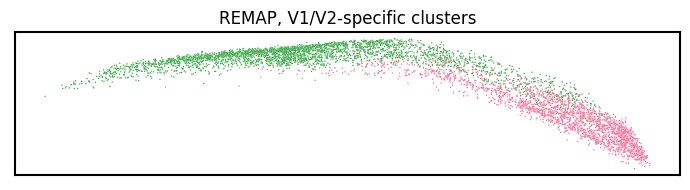

In [7]:
Qdata.obsm['remap'] = pred_test
Qdata.obs[['x_loc', 'y_loc']] = np.array(Qdata.obsm['remap'])

colors = {'EN-IT-UL-3': '#FEB915', 'EN-IT-UL-4': '#FFFF00', 'EN-IT-UL-2': '#199C28', 
          'EN-IT-L4-V1': '#F55887', 'EN-IT-UL-1': '#C798EE', 'EN-IT-DL-2': '#0000CD', 
          'EN-IT-DL-3': '#1E90FF', 'EN-IT-DL-1': '#3A84E6', 'EN-ET-2': '#DC143C', 
          'EN-ET-4': '#9ACD32', 'EN-ET-1': '#59BE86', 'EN-ET-3': '#D1D1D1', 'EN-ET-7': '#808000', 
          'EN-ET-5': '#6D1A9C', 'EN-ET-6': '#AF5F3C', 'EN-IT-UL-5': '#D2691E'}

Qdata_v1v2 = Qdata[Qdata.obs['Cluster'].isin(['EN-IT-L4-V1', 'EN-IT-UL-2'])].copy()


fig, axes = plt.subplots(1, 1, figsize=(7, 2))
sns.scatterplot(data=Qdata_v1v2.obs, x='x_loc', y='y_loc', s=1, hue='Cluster', 
                palette=colors, ax=axes, legend=False).set(title='REMAP, V1/V2-specific clusters', xlabel=None, ylabel=None)
axes.set_xticks([])
axes.set_yticks([])
for spine in axes.spines.values():
    spine.set_linewidth(1.5)  
plt.tight_layout()
plt.show()

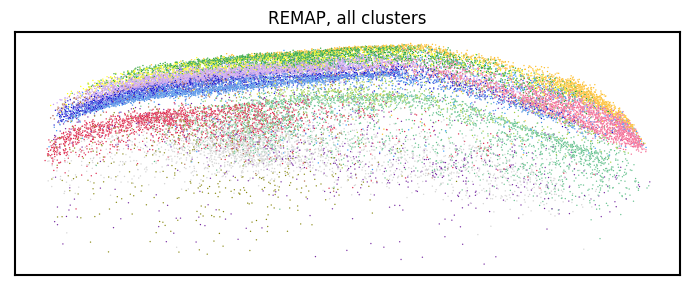

In [8]:
fig, axes = plt.subplots(1, 1, figsize=(7, 3))
sns.scatterplot(data=Qdata.obs, x='x_loc', y='y_loc', s=1, hue='Cluster', 
                palette=colors, ax=axes, legend=False).set(title='REMAP, all clusters', xlabel=None, ylabel=None)
axes.set_xticks([])
axes.set_yticks([])
for spine in axes.spines.values():
    spine.set_linewidth(1.5)  
plt.tight_layout()
plt.show()